# Plotter

In [1]:
from paths import *
import os
import pickle
import os
import time
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def draw_learning_curve_and_accuracy_new(data, type_names, task_names, epoch="", best_val=None, save=False, save_name=""): 
    plt.clf()
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    for task_id, task_name in enumerate(task_name): 
        ax = axes[task_id // 2, task_id % 2]
        for type_id, type_name in enumerate(type_names): 
            values = data[type_id][task_id]
            ax.plot(values, label=type_name)
        ax.set_title(f'Learning Curve {task_name}' + f" {epoch}")

    # Display the plots
    plt.tight_layout()
    plt.xlabel("Epoch")
    display.clear_output(wait=True)
    display.display(plt.gcf())
    if save: 
        plt.savefig(save_name)

<Figure size 640x480 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

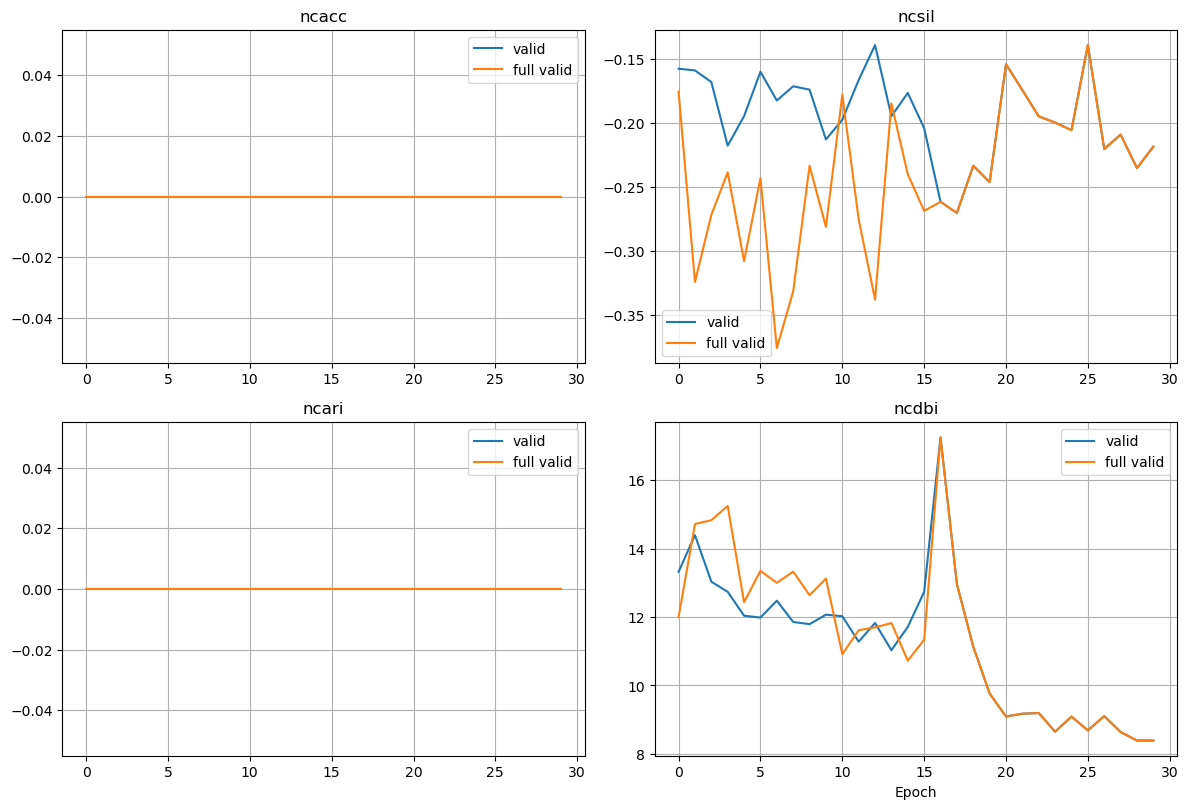

In [12]:
until = 30
ts = "0905105630"
pre_epoch = 15
type_prefix = "nc"
os.makedirs(os.path.join(model_save_, ts), exist_ok=True)
for run in range(1, 2): 
    for model in ["cnn", "reslin", "lstm"]: 
        for condition in ["lf", "hf"]: 
            if pre_epoch == 0 and condition == "hf": 
                continue
            to_plot_path = os.path.join(model_save_, f"H21-{ts}-{run}", f"{model}-{pre_epoch}-{30-pre_epoch}", "full", f"{condition}")
            plt.clf()
            fig, axes = plt.subplots(2, 2, figsize=(12, 8))
            # for task_idx, task in enumerate(["acc", "sil", "ari", "dbi"]): 
            for task_idx, task in enumerate([f"{type_prefix}acc", f"{type_prefix}sil", f"{type_prefix}ari", f"{type_prefix}dbi"]): 
            # for task_idx, task in enumerate(["newacc", "newsil", "newari", "newdbi"]):
                valid_res = os.path.join(to_plot_path, f"valid.{task}")
                full_valid_res = os.path.join(to_plot_path, f"full_valid.{task}")

                with open(valid_res, "rb") as f:
                    valid_list = pickle.load(f)
                with open(full_valid_res, "rb") as f:
                    full_valid_list = pickle.load(f)

                ax = axes[task_idx // 2, task_idx % 2]
                ax.plot(valid_list[:until], label="valid")
                ax.plot(full_valid_list[:until], label="full valid")
                ax.set_title(f'{task}')
                ax.legend()
                ax.grid(True)

            # Display the plots
            plt.tight_layout()
            plt.xlabel("Epoch")
            plt.savefig(os.path.join(model_save_, ts, f"clustering_{type_prefix}_{condition}_{model}_{run}_{pre_epoch}_{30-pre_epoch}.png"))

/tmp/ipykernel_4184578/401856267.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 1, figsize=(12, 8))


<Figure size 640x480 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

...

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

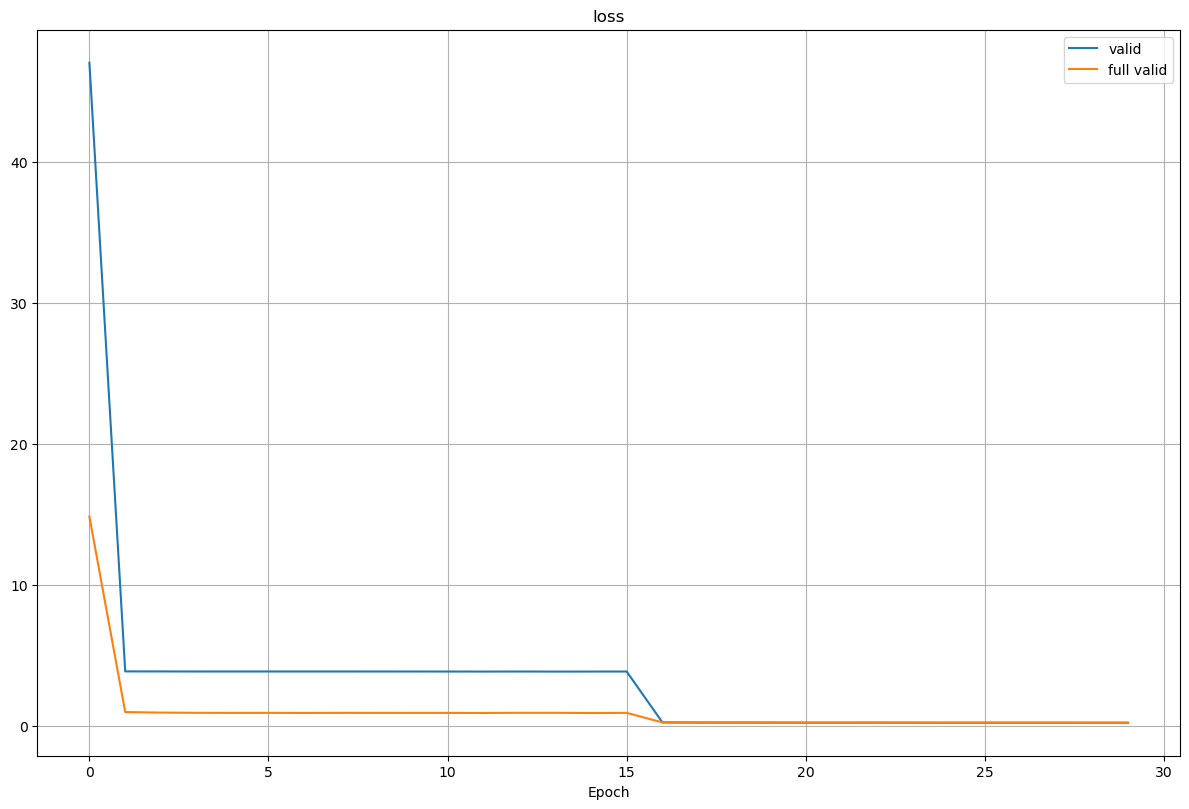

In [16]:
until = 30
for run in range(1, 6): 
    for model in ["cnn", "lstm", "reslin"]: 
        for condition in ["lf", "hf"]: 
            to_plot_path = os.path.join(model_save_, f"H21-0823122642-{run}", f"{model}-15-105", "full", f"{condition}")
            plt.clf()
            fig, axes = plt.subplots(1, 1, figsize=(12, 8))
            # for task_idx, task in enumerate(["acc", "sil", "ari", "dbi"]): 
            # for task_idx, task in enumerate(["ncacc", "ncsil", "ncari", "ncdbi"]): 
            task = "loss"
            valid_res = os.path.join(to_plot_path, f"valid.{task}")
            full_valid_res = os.path.join(to_plot_path, f"full_valid.{task}")
            special_res_path = os.path.join(model_save_, f"H21-0823122642-{run}", f"{model}-15-105", "full", f"{condition}", "special.hst")

            with open(valid_res, "rb") as f:
                valid_list = pickle.load(f)
            with open(full_valid_res, "rb") as f:
                full_valid_list = pickle.load(f)
            with open(special_res_path, "rb") as f:
                special_res = pickle.load(f)
            valid_list = [special_res["notrain-target-loss"]] + valid_list
            full_valid_list = [special_res["notrain-full-loss"]] + full_valid_list
            

            # ax = axes[task_idx // 2, task_idx % 2]
            ax = axes
            ax.plot(valid_list[:until], label="valid")
            ax.plot(full_valid_list[:until], label="full valid")
            ax.set_title(f'{task}')
            ax.legend()
            ax.grid(True)

            # Display the plots
            plt.tight_layout()
            plt.xlabel("Epoch")
            plt.savefig(os.path.join("to_plot", f"loss_{condition}_{model}_{run}.png"))